# Phan loai van ban y te - Demo huan luyen va danh gia
Notebook duoc chia theo tung buoc: nap du lieu, tien xu ly, huan luyen, danh gia, ve bieu do va ma tran nham lan, sau do demo du doan.

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import ipywidgets as widgets
from IPython.display import display, HTML

sns.set_theme(style='whitegrid')
print('Cell 1 OK: Da import thu vien thanh cong.')

Cell 1 OK: Da import thu vien thanh cong.


## 1) Nap du lieu va lam sach
Cell duoi se doc file CSV, xu ly encoding, giu 2 cot `Text` va `Label`, sau do hien thi thong tin nhanh ve du lieu.

In [2]:
csv_path = 'Clinical Text Data.csv'
df = None
for enc in ['utf-8-sig', 'cp1252', 'latin1']:
    try:
        df = pd.read_csv(csv_path, encoding=enc)
        print(f'Doc file thanh cong voi encoding: {enc}')
        break
    except UnicodeDecodeError:
        continue

if df is None:
    raise ValueError('Khong the doc file CSV voi cac encoding da thu.')

df = df[['Text', 'Label']].dropna().copy()
df['Text'] = df['Text'].astype(str).str.lower().str.strip()

print(f'Cell 2 OK: So mau sau lam sach = {len(df):,}')
print(f'So nhan = {df["Label"].nunique()}')
display(df.head(5))
display(df['Label'].value_counts().to_frame('count'))

Doc file thanh cong voi encoding: latin1
Cell 2 OK: So mau sau lam sach = 7,501
So nhan = 3


,Text,Label
0,thyroid surgery in children in a single insti...,Thyroid Research
1,""" the adopted strategy was the same as that us...",Thyroid Research
2,coronary arterybypass grafting thrombosis ï¬b...,Thyroid Research
3,solitary plasmacytoma sp of the skull is an un...,Thyroid Research
4,this study aimed to investigate serum matrix m...,Thyroid Research


,count
Label,
Thyroid Research,2810
Colorectal Studies,2511
Pulmonary Research,2180


## 2) Chia tap train/test va TF-IDF
Cell nay chia du lieu 80/20 (stratify theo nhan) va vector hoa van ban bang TF-IDF.

In [3]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['Text'],
    df['Label'],
    test_size=0.2,
    random_state=42,
    stratify=df['Label']
)

tfidf = TfidfVectorizer(max_features=5000)
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print('Cell 3 OK: Hoan tat chia tap va TF-IDF.')
print(f'X_train shape = {X_train.shape}')
print(f'X_test shape  = {X_test.shape}')
print(f'So tu vung TF-IDF = {len(tfidf.get_feature_names_out())}')

Cell 3 OK: Hoan tat chia tap va TF-IDF.
X_train shape = (6000, 5000)
X_test shape  = (1501, 5000)
So tu vung TF-IDF = 5000


## 3) Huan luyen tung mo hinh
Cell nay huan luyen 4 mo hinh: Logistic Regression, KNN, SVM (LinearSVC + calibration), Naive Bayes.
Dong thoi in ket qua Accuracy, Precision, Recall, F1 cho tung mo hinh.

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM (LinearSVC)': CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42, dual=False), cv=3),
    'Naive Bayes': MultinomialNB(alpha=1.0),
}

trained_models = {}
predictions = {}
results = []

print('Dang huan luyen cac mo hinh...')
for model_name, model in models.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - start

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )

    trained_models[model_name] = model
    predictions[model_name] = y_pred
    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision_weighted': precision,
        'Recall_weighted': recall,
        'F1_weighted': f1,
        'Train_time_sec': elapsed
    })

    print(f'- {model_name}: Accuracy={acc:.4f}, F1={f1:.4f}, Train time={elapsed:.3f}s')

Dang huan luyen cac mo hinh...
- Logistic Regression: Accuracy=0.9414, F1=0.9413, Train time=0.770s
- KNN: Accuracy=0.9980, F1=0.9980, Train time=0.013s
- SVM (LinearSVC): Accuracy=0.9534, F1=0.9534, Train time=2.977s
- Naive Bayes: Accuracy=0.8927, F1=0.8923, Train time=0.018s
Cell 4 OK: Da huan luyen xong tat ca mo hinh.


## 4) So sanh giua cac mo hinh
Cell nay hien bang tong hop metric va bieu do cot de so sanh Accuracy, F1, va thoi gian huan luyen.

,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Train_time_sec
0,KNN,0.9980,0.9980,0.9980,0.9980,0.013
1,SVM (LinearSVC),0.9534,0.9535,0.9534,0.9534,2.977
2,Logistic Regression,0.9414,0.9415,0.9414,0.9413,0.770
3,Naive Bayes,0.8927,0.8943,0.8927,0.8923,0.018


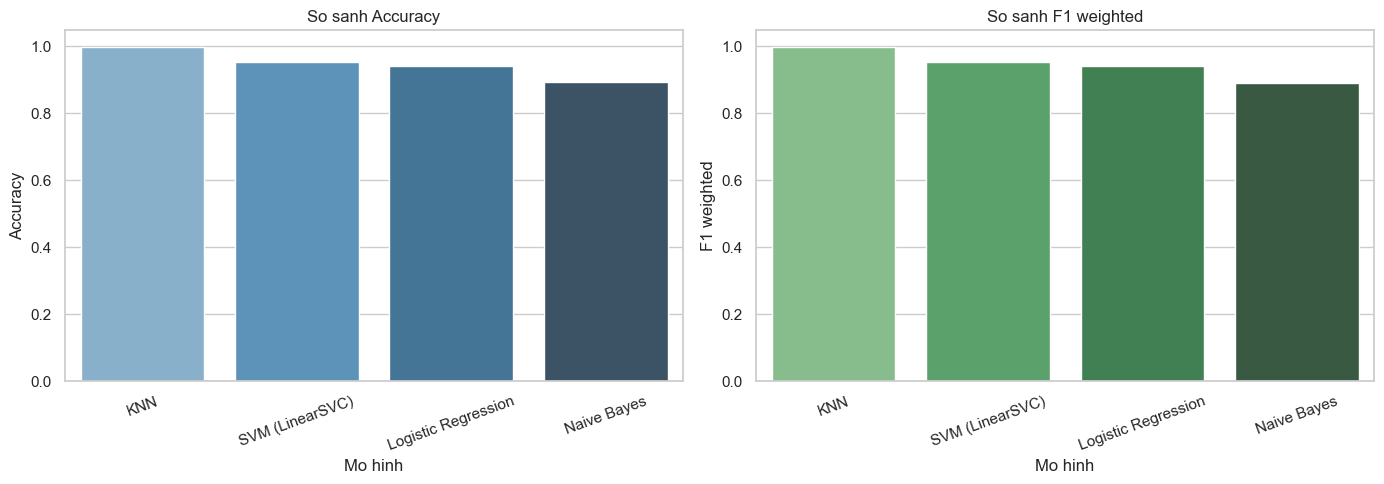

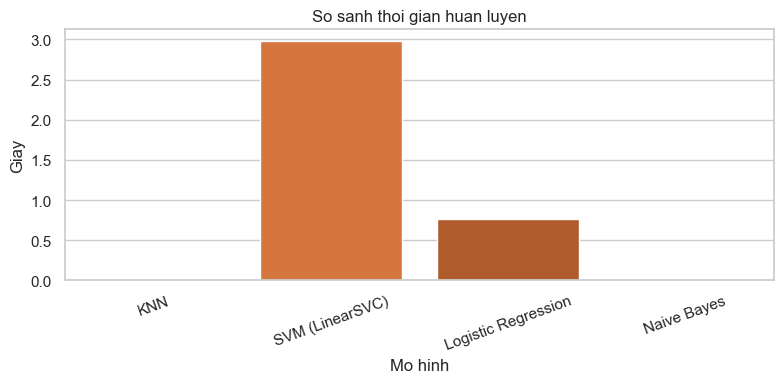

Cell 5 OK: Mo hinh tot nhat theo F1 weighted la: KNN


In [ ]:
results_df = pd.DataFrame(results).sort_values(by='F1_weighted', ascending=False).reset_index(drop=True)
display(results_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision_weighted': '{:.4f}',
    'Recall_weighted': '{:.4f}',
    'F1_weighted': '{:.4f}',
    'Train_time_sec': '{:.3f}'
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x='Model', y='Accuracy', hue='Model', palette='Blues_d', legend=False, ax=axes[0])
axes[0].set_title('So sanh Accuracy')
axes[0].set_xlabel('Mo hinh')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x='Model', y='F1_weighted', hue='Model', palette='Greens_d', legend=False, ax=axes[1])
axes[1].set_title('So sanh F1 weighted')
axes[1].set_xlabel('Mo hinh')
axes[1].set_ylabel('F1 weighted')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x='Model', y='Train_time_sec', hue='Model', palette='Oranges_d', legend=False)
plt.title('So sanh thoi gian huan luyen')
plt.xlabel('Mo hinh')
plt.ylabel('Giay')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

best_model_name = results_df.loc[0, 'Model']

## 5) Ma tran nham lan va bao cao phan loai
Cell nay ve confusion matrix cho tung mo hinh va in classification report de xem chi tiet theo tung lop.

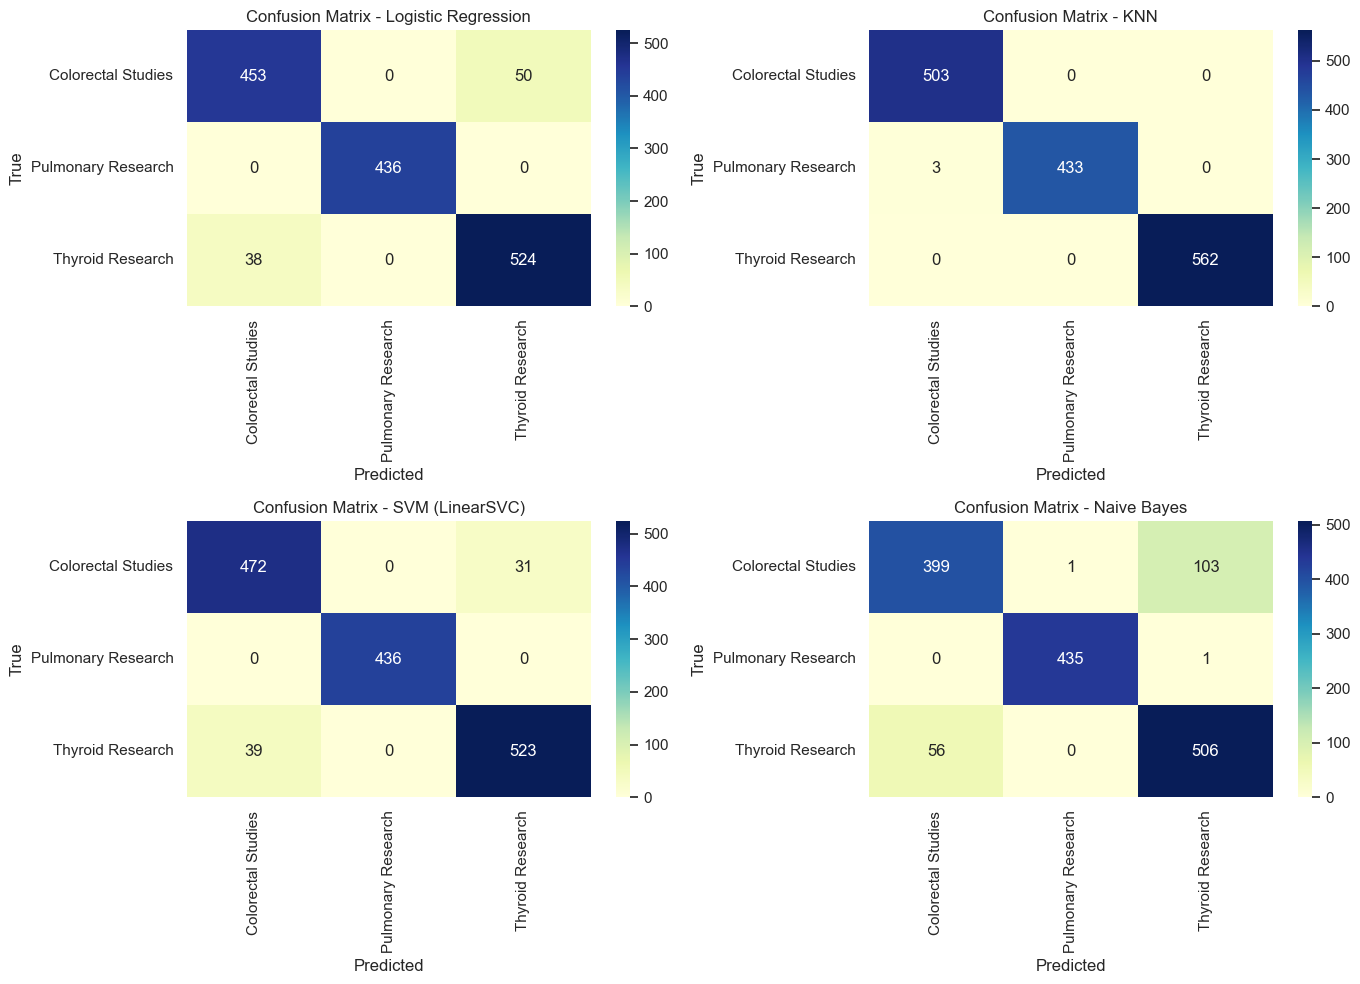

Classification report - Logistic Regression
                    precision    recall  f1-score   support

Colorectal Studies       0.92      0.90      0.91       503
Pulmonary Research       1.00      1.00      1.00       436
  Thyroid Research       0.91      0.93      0.92       562

          accuracy                           0.94      1501
         macro avg       0.95      0.94      0.94      1501
      weighted avg       0.94      0.94      0.94      1501

Classification report - KNN
                    precision    recall  f1-score   support

Colorectal Studies       0.99      1.00      1.00       503
Pulmonary Research       1.00      0.99      1.00       436
  Thyroid Research       1.00      1.00      1.00       562

          accuracy                           1.00      1501
         macro avg       1.00      1.00      1.00      1501
      weighted avg       1.00      1.00      1.00      1501

Classification report - SVM (LinearSVC)
                    precision    recall  f

In [ ]:
labels_sorted = sorted(y_test.unique())
n_models = len(trained_models)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='YlGnBu',
        xticklabels=labels_sorted,
        yticklabels=labels_sorted,
        ax=axes[idx]
    )
    axes[idx].set_title(f'Confusion Matrix - {model_name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.show()

for model_name, y_pred in predictions.items():
    print('=' * 80)
    print(f'Classification report - {model_name}')
    print(classification_report(y_test, y_pred, zero_division=0))

## 6) Giao dien demo du doan
Cell cuoi cung tao giao dien nhap van ban, chon mo hinh va xem nhan du doan cung xac suat (neu co).

In [ ]:
display(HTML("<h2 style='color:#2c3e50;'>He thong du doan phan loai ho so benh an</h2>"))

text_input = widgets.Textarea(
    value='',
    placeholder='Nhap trieu chung/noi dung benh an tai day...',
    description='Dau vao:',
    rows=5,
    style={'description_width': '100px'}
)

model_selector = widgets.Dropdown(
    options=list(trained_models.keys()),
    value='Logistic Regression',
    description='Mo hinh:',
    style={'description_width': '100px'}
)

predict_button = widgets.Button(
    description='Du doan',
    button_style='info',
    tooltip='Nhan de du doan',
    icon='play'
)

output_area = widgets.Output()

def predict(_):
    with output_area:
        output_area.clear_output()

        if not text_input.value.strip():
            display(HTML("<p style='color:red;'>Vui long nhap du lieu.</p>"))
            return

        text = text_input.value.lower().strip()
        text_vec = tfidf.transform([text])
        model_name = model_selector.value
        model = trained_models[model_name]

        prediction = model.predict(text_vec)[0]

        result_html = f"""
        <div style='border:2px solid #3498db; border-radius:10px; padding:16px; background-color:#f5fbff;'>
            <h3 style='color:#1f4e79;'>Ket qua du doan</h3>
            <p><b>Mo hinh:</b> {model_name}</p>
            <p><b>Nhan du doan:</b> <span style='color:#0d7a3e; font-size:18px; font-weight:bold;'>{prediction}</span></p>
        """

        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(text_vec)[0]
            classes = model.classes_
            pairs = sorted(zip(classes, probs), key=lambda x: x[1], reverse=True)
            result_html += "<p><b>Xac suat tung lop:</b></p><ul>"
            for class_name, prob in pairs:
                result_html += f"<li>{class_name}: {prob:.2%}</li>"
            result_html += "</ul>"

        result_html += "</div>"
        display(HTML(result_html))

predict_button.on_click(predict)

display(HTML("<hr>"))
display(HTML("<h4>Nhap thong tin benh nhan:</h4>"))
display(text_input)
display(HTML("<h4>Chon mo hinh du doan:</h4>"))
display(model_selector)
display(predict_button)
display(HTML("<h4>Ket qua:</h4>"))
display(output_area)

Textarea(value='', description='Dau vao:', placeholder='Nhap trieu chung/noi dung benh an tai day...', rows=5,…

Dropdown(description='Mo hinh:', options=('Logistic Regression', 'KNN', 'SVM (LinearSVC)', 'Naive Bayes'), sty…

Button(button_style='info', description='Du doan', icon='play', style=ButtonStyle(), tooltip='Nhan de du doan'…

Output()

Cell 7 OK: Da tao giao dien demo.
